In [ ]:
!pip install numpy
!pip install matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
grid_size = 5

goal_state = (4,4)

actions = {
    0: (-1,0),
    1: (1,0),
    2: (0,-1),
    3: (0,1)
}

num_actions = len(actions)

In [3]:
def step(state, action):

    next_state = (
        state[0] + actions[action][0],
        state[1] + actions[action][1]
    )

    if next_state[0] < 0 or next_state[0] >= grid_size:
        next_state = state

    if next_state[1] < 0 or next_state[1] >= grid_size:
        next_state = state

    if next_state == goal_state:
        reward = 10
    else:
        reward = -1

    return next_state, reward

In [4]:
Q = np.zeros((grid_size, grid_size, num_actions))

print(Q.shape)

(5, 5, 4)


In [5]:
alpha = 0.1

gamma = 0.9

epsilon = 0.1

episodes = 500

In [6]:
def choose_action(state):

    if np.random.rand() < epsilon:

        return np.random.randint(num_actions)

    else:

        return np.argmax(Q[state[0], state[1]])

In [7]:
rewards_per_episode = []

for episode in range(episodes):

    state = (0,0)

    action = choose_action(state)

    total_reward = 0

    done = False

    while not done:

        next_state, reward = step(state, action)

        next_action = choose_action(next_state)

        old_q = Q[state[0], state[1], action]

        next_q = Q[next_state[0], next_state[1], next_action]

        Q[state[0], state[1], action] = old_q + alpha * (
            reward + gamma * next_q - old_q
        )

        state = next_state

        action = next_action

        total_reward += reward

        if state == goal_state:
            done = True

    rewards_per_episode.append(total_reward)

print("Training Complete")

Training Complete


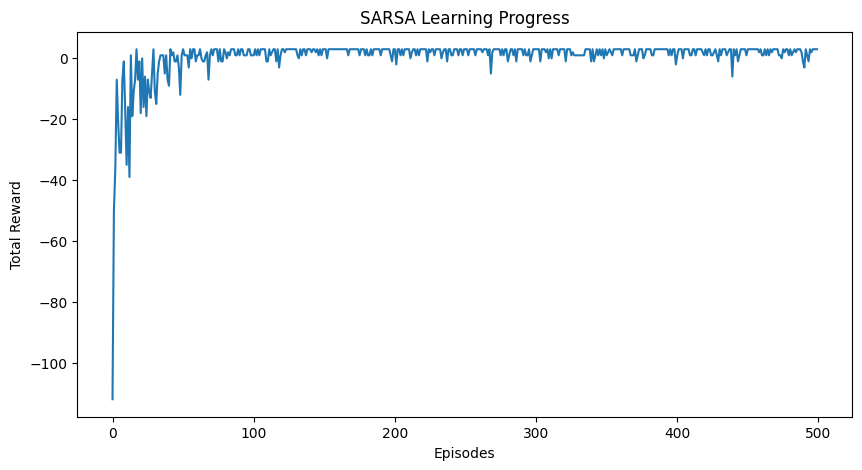

In [8]:
plt.figure(figsize=(10,5))

plt.plot(rewards_per_episode)

plt.xlabel("Episodes")

plt.ylabel("Total Reward")

plt.title("SARSA Learning Progress")

plt.show()

In [9]:
policy = np.full((grid_size, grid_size), ' ')

symbols = {
    0: '↑',
    1: '↓',
    2: '←',
    3: '→'
}

for i in range(grid_size):

    for j in range(grid_size):

        if (i,j) == goal_state:

            policy[i,j] = 'G'

        else:

            best_action = np.argmax(Q[i,j])

            policy[i,j] = symbols[best_action]

print(policy)

[['↓' '↓' '↓' '↓' '←']
 ['→' '→' '→' '↓' '↓']
 ['↓' '↓' '→' '↓' '↓']
 ['→' '→' '→' '→' '↓']
 ['←' '↑' '↑' '→' 'G']]


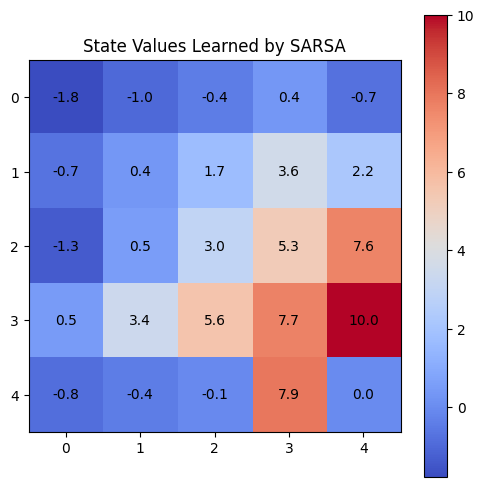

In [10]:
V = np.max(Q, axis=2)

plt.figure(figsize=(6,6))

plt.imshow(V, cmap='coolwarm')

for i in range(grid_size):

    for j in range(grid_size):

        plt.text(
            j,
            i,
            round(V[i,j],1),
            ha='center',
            va='center'
        )

plt.colorbar()

plt.title("State Values Learned by SARSA")

plt.show()